<a href="https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Google Colab Link :- https://colab.research.google.com/github/DevBatra05/PVR_Sem-6/blob/main/Exp-05.ipynb#scrollTo=7Ovh15RdXUxk

# Experiment No. 5
## Image Segmentation — Thresholding, Edge-Based and Region-Based Segmentation

---

### Aim
To explore classical image segmentation techniques — **Thresholding**, **Edge-Based Segmentation (Canny Edge Detection)**, and **Region-Based Segmentation (Watershed Algorithm)** — using OpenCV, and to partition an image into meaningful regions.

---

### Theory

#### What is Image Segmentation?
Image segmentation is the process of **dividing an image into multiple regions or segments**, where each region corresponds to a meaningful part of the image — such as an object, background, or boundary.

It is a fundamental step in computer vision tasks like object detection, medical imaging, and autonomous driving.

There are three classical approaches covered in this experiment:

---

#### 1. Thresholding
Thresholding is the **simplest form of segmentation**. It converts a grayscale image into a binary (black and white) image by comparing each pixel's intensity to a threshold value T:

- If pixel intensity >= T → White (255) — foreground
- If pixel intensity < T → Black (0) — background

**Formula:**
output(x, y) = 255   if input(x, y) >= T

0     if input(x, y) < T

The choice of T directly affects the result:
- Too low T → most pixels become white (over-segmented)
- Too high T → most pixels become black (under-segmented)
- Otsu's method automatically finds the best T by minimizing intra-class variance

---

#### 2. Edge-Based Segmentation — Canny Edge Detection
Instead of looking at pixel intensity regions, edge-based methods look for **boundaries** between regions — where pixel intensity changes rapidly (high gradient).

The **Canny Edge Detector** is a multi-step algorithm:

**Step 1 — Gaussian Blur:** Smooth the image to reduce noise before gradient computation.

**Step 2 — Gradient Computation (Sobel):** Compute gradient magnitude and direction at every pixel using Sobel filters in X and Y directions.

**Step 3 — Non-Maximum Suppression:** Thin edges to 1 pixel wide by keeping only local maxima along the gradient direction.

**Step 4 — Double Thresholding:** Classify pixels as:
- Strong edge (above high threshold)
- Weak edge (between low and high threshold)
- Non-edge (below low threshold)

**Step 5 — Edge Tracking by Hysteresis:** Keep weak edges only if they are connected to a strong edge. This removes false/broken edges.

---

#### 3. Region-Based Segmentation — Watershed Algorithm
The Watershed algorithm treats a grayscale image like a **topographic map** — pixel intensity = altitude. Water is poured from local minima (dark regions). Where water from two different sources meets, a watershed boundary (dam) is built.

Steps used in this implementation:

**Step 1 — Otsu Thresholding:** Separate foreground from background automatically.

**Step 2 — Morphological Opening:** Remove small noise using erosion followed by dilation.

**Step 3 — Dilation:** Expand the sure-foreground region to estimate the sure-background.

**Step 4 — Distance Transform:** For each foreground pixel, compute its distance to the nearest background pixel. Peaks in this map = centers of objects.

**Step 5 — Sure Foreground:** Threshold the distance transform to get definite object centers.

**Step 6 — Unknown Region:** The area between sure-foreground and sure-background — where we are not certain.

**Step 7 — Marker Labeling:** Label each sure-foreground region with a unique integer using connected components.

**Step 8 — Watershed:** Apply the watershed algorithm. Boundaries are marked with -1 and highlighted in red on the original image.

---
## Part A: Thresholding

We apply manual thresholding at four different values — T = 50, 100, 150, 200 — on the same image and observe how the segmentation changes.

The image is loaded directly from a URL using urllib and decoded using OpenCV.

In [ ]:
# Install required libraries (only needed in Colab)
!pip install opencv-python-headless matplotlib

# OpenCV — for image processing operations
import cv2

# NumPy — for array manipulation
import numpy as np

# urllib — to load image from a URL
import urllib.request

# Matplotlib — for displaying images
import matplotlib.pyplot as plt

Image Shape: (800, 800, 3)
Image Data Type: uint8
Manual Threshold Value Used: 50


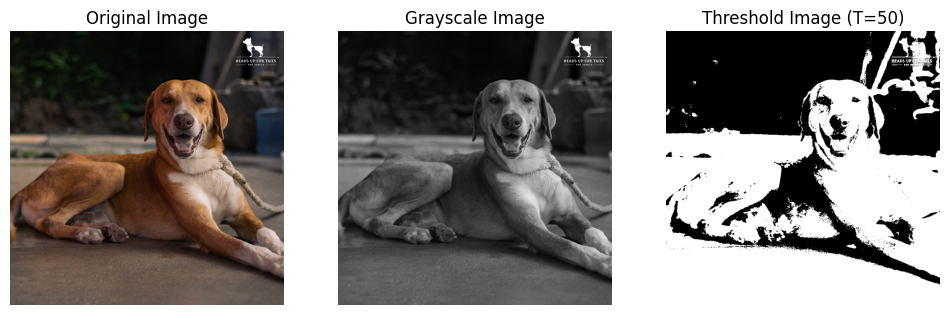

In [ ]:
# Image URL — a dog image loaded directly from the web
url = "https://cdn.shopify.com/s/files/1/0086/0795/7054/files/Indie.jpg?v=1645179817"

# Read the image bytes from the URL
resp  = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")

# Decode the bytes into an OpenCV image (BGR format)
img = cv2.imdecode(image, cv2.IMREAD_COLOR)

# Print image properties
print("Image Shape:", img.shape)       # (height, width, channels)
print("Image Data Type:", img.dtype)   # uint8 = values from 0 to 255

# Convert to grayscale — thresholding works on single channel images
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Set threshold value
threshold_value = 50

# Apply binary threshold:
# pixels >= 50 become 255 (white), pixels < 50 become 0 (black)
ret, thresh_img = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Manual Threshold Value Used:", threshold_value)

# Display original, grayscale, and thresholded images side by side
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # convert BGR to RGB for matplotlib
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Threshold Image (T=50)")
plt.imshow(thresh_img, cmap='gray')
plt.axis('off')

plt.show()

Image Shape: (800, 800, 3)
Image Data Type: uint8
Manual Threshold Value Used: 100


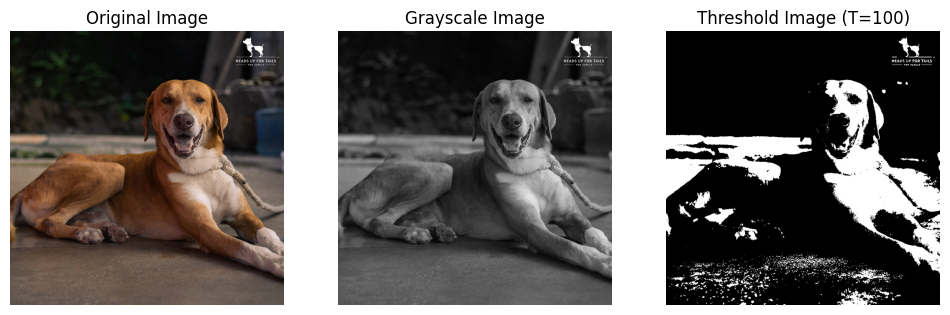

In [ ]:
# Reload the image fresh for a clean experiment at T=100
resp  = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img   = cv2.imdecode(image, cv2.IMREAD_COLOR)

print("Image Shape:", img.shape)
print("Image Data Type:", img.dtype)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Higher threshold — fewer pixels classified as foreground (white)
threshold_value = 100

ret, thresh_img = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Manual Threshold Value Used:", threshold_value)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Threshold Image (T=100)")
plt.imshow(thresh_img, cmap='gray')
plt.axis('off')

plt.show()

Image Shape: (800, 800, 3)
Image Data Type: uint8
Manual Threshold Value Used: 150


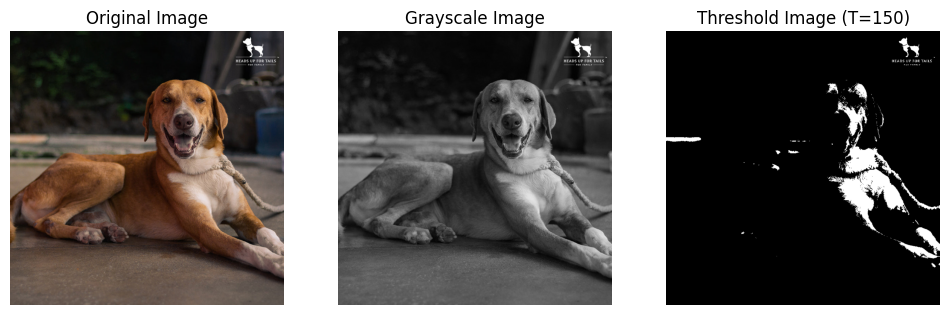

In [ ]:
# Reload image for T=150
resp  = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img   = cv2.imdecode(image, cv2.IMREAD_COLOR)

print("Image Shape:", img.shape)
print("Image Data Type:", img.dtype)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# T=150 — only bright pixels remain as foreground
threshold_value = 150

ret, thresh_img = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Manual Threshold Value Used:", threshold_value)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Threshold Image (T=150)")
plt.imshow(thresh_img, cmap='gray')
plt.axis('off')

plt.show()

Image Shape: (800, 800, 3)
Image Data Type: uint8
Manual Threshold Value Used: 200


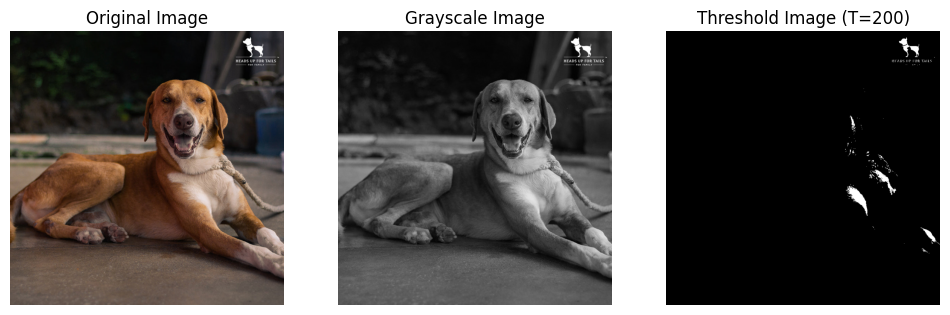

In [ ]:
# Reload image for T=200
resp  = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
img   = cv2.imdecode(image, cv2.IMREAD_COLOR)

print("Image Shape:", img.shape)
print("Image Data Type:", img.dtype)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# T=200 — very high threshold, only the brightest pixels remain
threshold_value = 200

ret, thresh_img = cv2.threshold(gray, threshold_value, 255, cv2.THRESH_BINARY)

print("Manual Threshold Value Used:", threshold_value)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grayscale Image")
plt.imshow(gray, cmap='gray')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Threshold Image (T=200)")
plt.imshow(thresh_img, cmap='gray')
plt.axis('off')

plt.show()

---
## Part B: Edge-Based Segmentation — Canny Edge Detector (from scratch)

We implement the full Canny Edge Detection pipeline from scratch using NumPy and OpenCV for gradient computation only.

The five steps are:
1. Gaussian Blur — reduce noise
2. Sobel Gradients — find intensity changes
3. Non-Maximum Suppression — thin edges to 1 pixel
4. Double Thresholding — classify strong, weak, and non-edges
5. Edge Tracking by Hysteresis — connect weak edges to strong ones

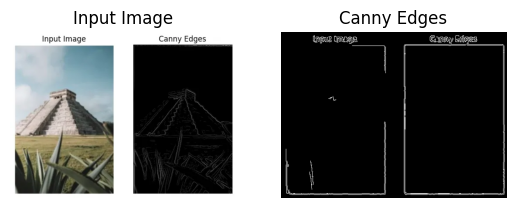

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import urllib.request


def Canny_detector(img, weak_th=None, strong_th=None):

    # Step 1: Convert to grayscale — edges are computed on intensity, not color
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    height, width = img.shape

    # Step 2: Gaussian Blur — smooths the image to reduce noise before gradient computation
    img = cv2.GaussianBlur(img, (5, 5), 1.4)

    # Step 3: Compute Sobel gradients in X and Y directions
    # gx detects vertical edges, gy detects horizontal edges
    gx = cv2.Sobel(np.float32(img), cv2.CV_64F, 1, 0, 3)
    gy = cv2.Sobel(np.float32(img), cv2.CV_64F, 0, 1, 3)

    # Convert (gx, gy) to polar form: magnitude and angle
    # magnitude = how strong the edge is
    # angle = direction of the gradient (perpendicular to edge)
    mag, ang = cv2.cartToPolar(gx, gy, angleInDegrees=True)

    # Set thresholds as fractions of max magnitude if not provided
    mag_max = np.max(mag)
    if weak_th is None:
        weak_th = mag_max * 0.1     # 10% of max = weak edge threshold
    if strong_th is None:
        strong_th = mag_max * 0.5   # 50% of max = strong edge threshold

    # Step 4: Non-Maximum Suppression
    # For each pixel, check its two neighbors along the gradient direction
    # If this pixel is not the local maximum, suppress it (set to 0)
    for i_x in range(1, width - 1):
        for i_y in range(1, height - 1):

            grad_ang = ang[i_y, i_x]
            grad_ang = abs(grad_ang - 180) if abs(grad_ang) > 180 else abs(grad_ang)

            # Determine which two neighbors to compare based on gradient direction
            if grad_ang <= 22.5:               # horizontal edge
                n1 = mag[i_y, i_x - 1]
                n2 = mag[i_y, i_x + 1]
            elif grad_ang <= 67.5:             # diagonal edge
                n1 = mag[i_y - 1, i_x - 1]
                n2 = mag[i_y + 1, i_x + 1]
            elif grad_ang <= 112.5:            # vertical edge
                n1 = mag[i_y - 1, i_x]
                n2 = mag[i_y + 1, i_x]
            elif grad_ang <= 157.5:            # other diagonal
                n1 = mag[i_y + 1, i_x - 1]
                n2 = mag[i_y - 1, i_x + 1]
            else:
                n1 = mag[i_y, i_x - 1]
                n2 = mag[i_y, i_x + 1]

            # Suppress if not local maximum
            if mag[i_y, i_x] < n1 or mag[i_y, i_x] < n2:
                mag[i_y, i_x] = 0

    # Step 5: Double Thresholding
    # Classify each pixel as: non-edge (0), weak edge (1), strong edge (2)
    res  = np.zeros_like(mag)
    weak   = 1
    strong = 2

    for i_x in range(width):
        for i_y in range(height):
            if mag[i_y, i_x] < weak_th:
                res[i_y, i_x] = 0        # non-edge
            elif weak_th <= mag[i_y, i_x] < strong_th:
                res[i_y, i_x] = weak     # weak edge — uncertain
            else:
                res[i_y, i_x] = strong   # strong edge — definite

    # Step 6: Edge Tracking by Hysteresis
    # Keep a weak edge only if at least one of its 8 neighbors is a strong edge
    for i_x in range(1, width - 1):
        for i_y in range(1, height - 1):
            if res[i_y, i_x] == weak:
                if np.any(res[i_y-1:i_y+2, i_x-1:i_x+2] == strong):
                    res[i_y, i_x] = strong   # promote to strong edge
                else:
                    res[i_y, i_x] = 0        # remove isolated weak edge

    return res


# Load image from URL
url  = "https://media.geeksforgeeks.org/wp-content/uploads/20250725154132632455/canny.webp"
resp = urllib.request.urlopen(url)
image = np.asarray(bytearray(resp.read()), dtype="uint8")
frame = cv2.imdecode(image, cv2.IMREAD_COLOR)

if frame is None:
    print("Error: image not loaded!")
    exit()

# Apply our custom Canny detector
canny_img = Canny_detector(frame)

# Display input and edge output
plt.subplot(1, 2, 1)
plt.title('Input Image')
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Canny Edges')
plt.imshow(canny_img, cmap='gray')
plt.axis('off')

plt.show()

---
## Part C: Region-Based Segmentation — Watershed Algorithm

The Watershed algorithm segments an image by treating it like a flooded landscape. It is particularly useful for **separating touching or overlapping objects**.

We demonstrate it on two images — an animals image and a coins image — following a 9-step pipeline.

The key idea is to identify:
- **Sure foreground** — definitely part of an object
- **Sure background** — definitely not part of any object
- **Unknown region** — the boundary area in between (where watershed draws the lines)

In [ ]:
def apply_morphology(img):
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Otsu thresholding: automatically finds the best threshold value
    # THRESH_BINARY_INV makes the foreground dark objects become white
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Morphological Opening = Erosion followed by Dilation
    # Removes small noise (white specks) from the binary image
    kernel  = np.ones((3, 3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    return opening


def apply_dilation(img):
    # Dilation expands white regions outward
    # Used to get the "sure background" — region definitely not an object center
    kernel   = np.ones((3, 3), np.uint8)
    dilation = cv2.dilate(img, kernel, iterations=3)
    return dilation


def apply_distance_transform(img):
    # Distance Transform: for each foreground pixel, compute its distance
    # to the nearest background pixel
    # Peaks in the distance map = centers of objects (sure foreground)
    dist_transform = cv2.distanceTransform(img, cv2.DIST_L2, 5)

    # Normalize to 0-1 range for clean visualization
    dist_norm = cv2.normalize(dist_transform, None, 0, 1.0, cv2.NORM_MINMAX)

    return dist_transform, dist_norm


def apply_watershed(original_img, sure_fg, sure_bg):
    # Unknown region = sure_bg minus sure_fg
    # These are pixels we are not certain about
    unknown = cv2.subtract(sure_bg, sure_fg)

    # Connected Components: label each separate foreground object with a unique integer
    _, markers = cv2.connectedComponents(sure_fg)

    # Add 1 to all markers so background is 1, not 0
    markers = markers + 1

    # Mark the unknown region as 0 — watershed will fill these in
    markers[unknown == 255] = 0

    # Apply Watershed: fills unknown regions and marks boundaries as -1
    markers = cv2.watershed(original_img, markers)

    # Draw boundaries in red on the original image
    original_img[markers == -1] = [255, 0, 0]

    return original_img, markers

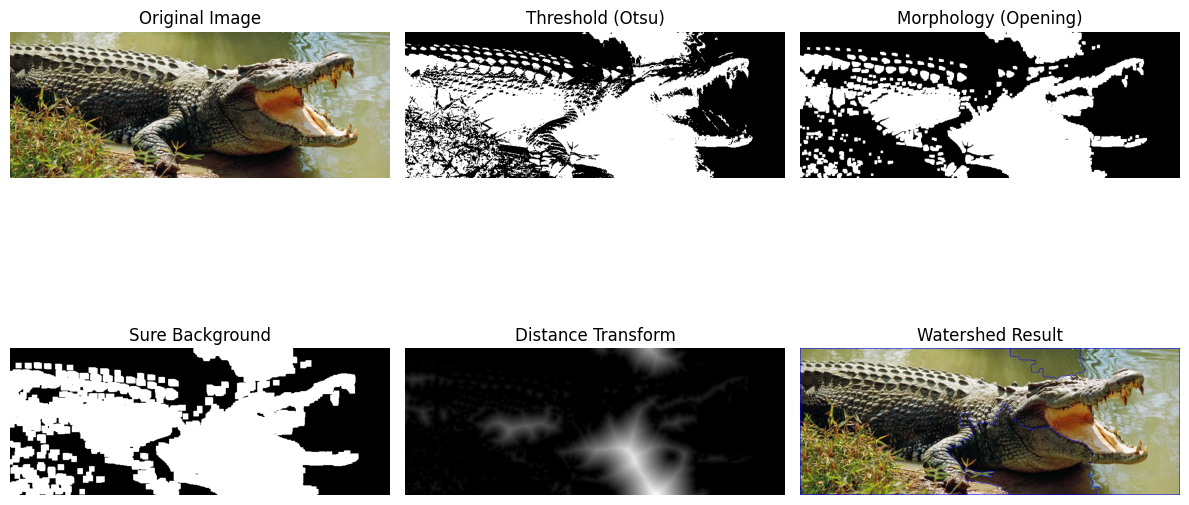

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests

# Load image from URL
url  = "https://www.thinkingaustralia.com/wp-content/uploads/2015/03/TA_ANIMALS_DETAIL_01_03-750x290.jpg"
resp = requests.get(url)
image = np.asarray(bytearray(resp.content), dtype="uint8")
img   = cv2.imdecode(image, cv2.IMREAD_COLOR)

if img is None:
    print("Error loading image")
    exit()

# Keep a clean RGB copy for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 1: Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Otsu Thresholding — automatically separate foreground from background
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Step 3: Morphological Opening — remove small noise from binary image
kernel  = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 4: Dilation — expand sure foreground to estimate sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Step 5: Distance Transform — find object centers (peaks = centers)
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Step 6: Threshold distance map to get sure foreground (object centers)
# 0.6 * max means we only keep the top 40% distance values as sure foreground
_, sure_fg = cv2.threshold(dist_transform, 0.6 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Step 7: Unknown region = sure background minus sure foreground
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 8: Label connected components — each object gets a unique ID
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1           # background = 1 (not 0)
markers[unknown == 255] = 0     # unknown region = 0 for watershed to fill

# Step 9: Apply Watershed — marks boundaries as -1
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]  # draw boundaries in red

# Visualize all steps
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Threshold (Otsu)")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Morphology (Opening)")
plt.imshow(opening, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Sure Background")
plt.imshow(sure_bg, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Watershed Result")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

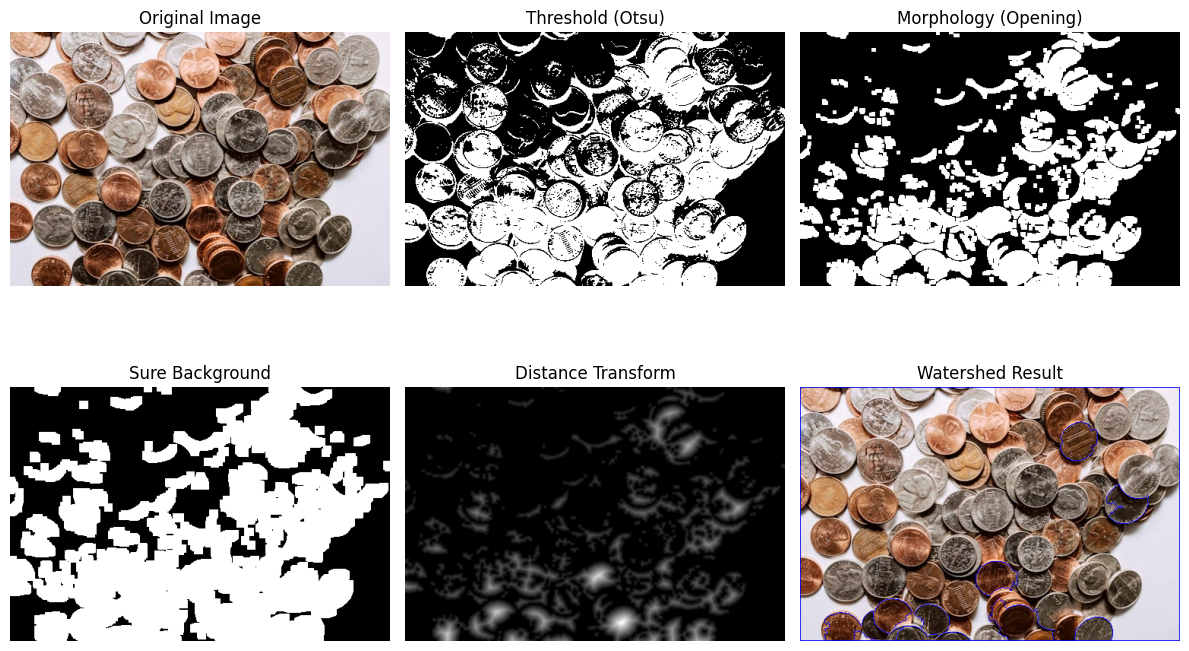

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import requests

# Load coins image — good test case since coins are circular and touching
url     = "https://plus.unsplash.com/premium_photo-1681437744790-56cd2750bc80?w=500&auto=format&fit=crop&q=60"
headers = {"User-Agent": "Mozilla/5.0"}
resp    = requests.get(url, headers=headers)

image = np.asarray(bytearray(resp.content), dtype="uint8")
img   = cv2.imdecode(image, cv2.IMREAD_COLOR)

if img is None:
    print("Error loading image")
    exit()

# Keep clean RGB copy
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 1: Grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 2: Otsu Thresholding
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Step 3: Morphological Opening — clean binary image
kernel  = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Step 4: Dilation — sure background
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Step 5: Distance Transform
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)

# Step 6: Sure foreground — peaks in distance map
_, sure_fg = cv2.threshold(dist_transform, 0.6 * dist_transform.max(), 255, 0)
sure_fg = np.uint8(sure_fg)

# Step 7: Unknown region
unknown = cv2.subtract(sure_bg, sure_fg)

# Step 8: Marker labeling
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown == 255] = 0

# Step 9: Watershed Algorithm
markers = cv2.watershed(img, markers)
img[markers == -1] = [255, 0, 0]   # mark boundaries in red

# Visualize
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis('off')

plt.subplot(2, 3, 2)
plt.title("Threshold (Otsu)")
plt.imshow(thresh, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.title("Morphology (Opening)")
plt.imshow(opening, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.title("Sure Background")
plt.imshow(sure_bg, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.title("Distance Transform")
plt.imshow(dist_transform, cmap='gray')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.title("Watershed Result")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.tight_layout()
plt.show()

---
### Conclusion

In this experiment, we explored three classical image segmentation techniques:

**1. Thresholding**
We applied manual binary thresholding at T = 50, 100, 150, and 200. As the threshold increased, fewer pixels were classified as foreground. This showed that the choice of threshold directly controls what gets segmented. Otsu's method removes this manual guesswork by finding the optimal T automatically.

**2. Edge-Based Segmentation — Canny Edge Detector**
We implemented the full Canny pipeline from scratch — Gaussian blur, Sobel gradients, Non-Maximum Suppression, Double Thresholding, and Hysteresis. The result was a clean 1-pixel-wide edge map that accurately traced object boundaries.

**3. Region-Based Segmentation — Watershed Algorithm**
We applied Watershed to both an animals image and a coins image. The algorithm successfully separated touching objects by identifying sure foreground (object centers via distance transform) and sure background (via dilation), then flooding the unknown boundary regions.

Key Observation: Each technique has a different strength — thresholding is simple and fast, edge detection captures boundaries accurately, and watershed is best for separating overlapping or touching objects.